# KNN Smoke Detection Model

This notebook trains and evaluates a K-Nearest Neighbors classifier for smoke-related event classification. It reuses the same prepared IoT and Blattmann datasets, feature columns, train/test split approach, scaling method, and evaluation style used in the Random Forest notebook.

KNN is included because it is a simple distance-based model that classifies new sensor readings by comparing them with nearby examples in the training data. This makes it useful as a comparison model against Random Forest and helps test whether local similarity between sensor readings is enough to separate Normal, Cooking, and Fire cases.

#### 1. Imports
Import the libraries needed for data handling, plotting, scaling, KNN training, cross-validation, and evaluation.

In [5]:
# Import all libraries in one place.
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


#### 2. Settings
Define the input files, selected sensor features, class names, and random state so the workflow stays reproducible.

In [6]:
# Define files, feature columns, class names, and random state.
notebook_folder = Path('.').resolve()

iot_file = notebook_folder / 'iot_clean_data.xlsx'
blattmann_file = notebook_folder / 'blattmann_clean_data.xlsx'

feature_col = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']
class_names = ['Normal', 'Cooking', 'Fire']
random_state = 42


#### 3. Load Prepared Data
Load the cleaned IoT and Blattmann datasets. Blattmann smoke readings are remapped to the project class Fire so both datasets follow the same class structure.

In [7]:
# Load the prepared IoT and Blattmann datasets separately.
iot_data = pd.read_excel(iot_file)
blattmann_data = pd.read_excel(blattmann_file, sheet_name='Blattmann Processed')

if 'label' in blattmann_data.columns:
    blattmann_data = blattmann_data.rename(columns={'label': 'blattmann_label'})

blattmann_data['class_id'] = blattmann_data['blattmann_label'].map({
    'No Smoke': 0,
    'Smoke': 2,
    'Normal': 0,
    'Fire': 2,
    0: 0,
    2: 2,
})

blattmann_data['label'] = blattmann_data['class_id'].map({
    0: 'Normal',
    2: 'Fire',
})

blattmann_data = blattmann_data.dropna(subset=['class_id'] + feature_col)
blattmann_data['class_id'] = blattmann_data['class_id'].astype(int)

print('IoT samples:', len(iot_data))
print(iot_data['label'].value_counts().to_string())

print('\nBlattmann samples:', len(blattmann_data))
print(blattmann_data['label'].value_counts().to_string())

display(iot_data.head())
display(blattmann_data.head())


IoT samples: 549
label
Cooking    329
Normal     220

Blattmann samples: 62630
label
Fire      44757
Normal    17873


,label,class_id,temperature,humidity,tvoc_ppb,eco2_ppm
0,Normal,0,21.8,32,29,413
1,Normal,0,21.8,32,35,426
2,Normal,0,21.8,32,28,409
3,Normal,0,21.8,32,25,402
4,Normal,0,21.8,32,29,413


,temperature,humidity,tvoc_ppb,eco2_ppm,blattmann_label,class_id,label
0,20.000,57.36,0,400,No Smoke,0,Normal
1,20.015,56.67,0,400,No Smoke,0,Normal
2,20.029,55.96,0,400,No Smoke,0,Normal
3,20.044,55.28,0,400,No Smoke,0,Normal
4,20.059,54.69,0,400,No Smoke,0,Normal


#### 4. Feature Distributions
Visualize feature distributions to understand how Normal, Cooking, and Fire readings differ across the two datasets.

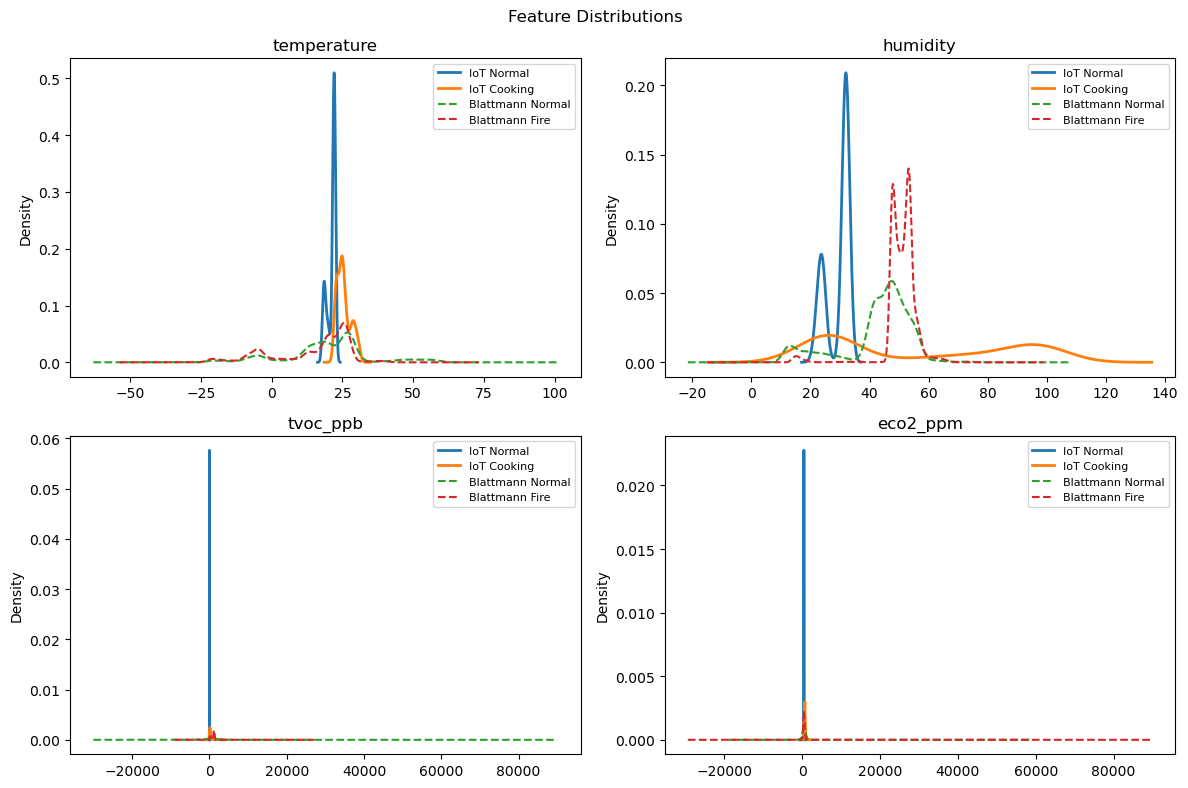

In [8]:
# Plot feature distributions per class and dataset.
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions')

for ax, feature in zip(axes.flat, feature_col):
    for class_id, class_name in [(0, 'Normal'), (1, 'Cooking')]:
        values = iot_data[iot_data['class_id'] == class_id][feature]
        if len(values) > 1:
            values.plot.kde(ax=ax, label=f'IoT {class_name}', linewidth=2)

    for class_id, class_name in [(0, 'Normal'), (2, 'Fire')]:
        values = blattmann_data[blattmann_data['class_id'] == class_id][feature]
        if len(values) > 1:
            values.plot.kde(ax=ax, label=f'Blattmann {class_name}', linewidth=1.5, linestyle='--')

    ax.set_title(feature)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


#### 5. Split Each Dataset Separately
Split IoT and Blattmann separately before combining training data, so each source keeps its own test set for evaluation.

In [9]:
# Split each dataset separately, then combine training data in memory.
X_blattmann_train, X_blattmann_test, y_blattmann_train, y_blattmann_test = train_test_split(
    blattmann_data[feature_col],
    blattmann_data['class_id'],
    test_size=0.2,
    random_state=random_state,
    stratify=blattmann_data['class_id']
)

X_iot_train, X_iot_test, y_iot_train, y_iot_test = train_test_split(
    iot_data[feature_col],
    iot_data['class_id'],
    test_size=0.2,
    random_state=random_state,
    stratify=iot_data['class_id']
)

X_train = pd.concat([X_blattmann_train, X_iot_train], ignore_index=True)
y_train = pd.concat([y_blattmann_train, y_iot_train], ignore_index=True)

print('Train:', len(y_train))
print('Blattmann test:', len(y_blattmann_test))
print('IoT test:', len(y_iot_test))

for class_id, class_name in enumerate(class_names):
    count = (y_train == class_id).sum()
    if count:
        print(f'{class_name}: {count}')


Train: 50543
Blattmann test: 12526
IoT test: 110
Normal: 14474
Cooking: 263
Fire: 35806


#### 6. Scale Features
Scale the features using the training data only. This is especially important for KNN because distance calculations are affected by feature magnitude.

In [10]:
# Fit scaler on train only — applying to test avoids data leakage, then transform both test sets.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_blattmann_test_sc = scaler.transform(X_blattmann_test)
X_iot_test_sc = scaler.transform(X_iot_test)

joblib.dump(scaler, notebook_folder / 'scaler_knn.joblib')


['C:\\Users\\waqar\\SEP4\\System\\MlServer\\waqars_model\\scaler_knn.joblib']

#### 7. Tune KNN Neighbors
Compare several neighbor counts using stratified cross-validation and select the best k value based on macro F1-score.

,n_neighbors,mean_f1_macro,std_f1_macro
0,3,0.9821,0.0032
1,5,0.9802,0.0041
2,7,0.9770,0.0057
3,9,0.9738,0.0077
4,11,0.9737,0.0071
5,15,0.9665,0.0118
6,21,0.9648,0.0118


Best k: 3


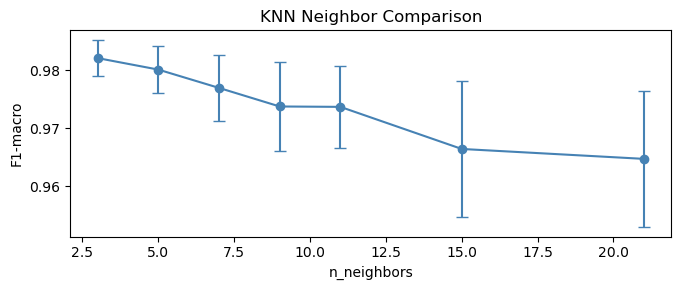

In [11]:
# Compare a few neighbor values with cross-validation.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
neighbor_options = [3, 5, 7, 9, 11, 15, 21]
neighbor_scores = []

for n_neighbors in neighbor_options:
    candidate = KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance', n_jobs=-1)
    scores = cross_val_score(candidate, X_train_sc, y_train, cv=skf, scoring='f1_macro')
    neighbor_scores.append({
        'n_neighbors': n_neighbors,
        'mean_f1_macro': scores.mean(),
        'std_f1_macro': scores.std(),
    })

neighbor_results = pd.DataFrame(neighbor_scores).sort_values('mean_f1_macro', ascending=False)
display(neighbor_results.round(4))

best_k = int(neighbor_results.iloc[0]['n_neighbors'])
print('Best k:', best_k)

plt.figure(figsize=(7, 3))
plt.errorbar(
    neighbor_results.sort_values('n_neighbors')['n_neighbors'],
    neighbor_results.sort_values('n_neighbors')['mean_f1_macro'],
    yerr=neighbor_results.sort_values('n_neighbors')['std_f1_macro'],
    marker='o',
    color='steelblue',
    capsize=4,
)
plt.xlabel('n_neighbors')
plt.ylabel('F1-macro')
plt.title('KNN Neighbor Comparison')
plt.tight_layout()
plt.show()


#### 8. Train KNN
Train the final KNN model using the selected neighbor count and save the model artifact.

In [12]:
# Train the KNN model.
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights='distance',
    n_jobs=-1
)

knn.fit(X_train_sc, y_train)

joblib.dump(knn, notebook_folder / 'model_knn.joblib')


['C:\\Users\\waqar\\SEP4\\System\\MlServer\\waqars_model\\model_knn.joblib']

#### 9. Cross-Validation
Evaluate the final KNN model on the combined training set using 5-fold stratified cross-validation.

Cross-validation F1-macro: 0.9821 +/- 0.0032


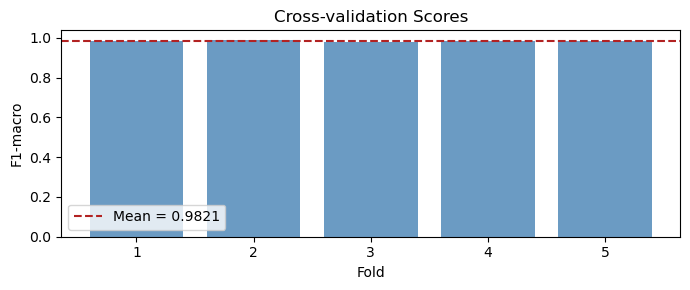

In [15]:
# Run cross-validation on the training data.
cv_scores = cross_val_score(knn, X_train_sc, y_train, cv=skf, scoring='f1_macro')

print(f'Cross-validation F1-macro: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

plt.figure(figsize=(7, 3))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8)
plt.axhline(cv_scores.mean(), color='firebrick', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')

plt.xlabel('Fold')
plt.ylabel('F1-macro')
plt.title('Cross-validation Scores')
plt.legend()
plt.tight_layout()
plt.show()


#### 10. Test Set Evaluation
Evaluate predictions separately on the Blattmann and IoT test sets using precision, recall, and F1-score.

In [16]:
# Predict and evaluate on both test sets.
y_blattmann_pred = knn.predict(X_blattmann_test_sc)
y_iot_pred = knn.predict(X_iot_test_sc)

print('Blattmann test set')
print(classification_report(y_blattmann_test, y_blattmann_pred, target_names=class_names, labels=[0, 1, 2], zero_division=0))

print('IoT test set')
print(classification_report(y_iot_test, y_iot_pred, target_names=class_names, labels=[0, 1, 2], zero_division=0))


Blattmann test set
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      3575
     Cooking       0.00      0.00      0.00         0
        Fire       0.99      1.00      1.00      8951

    accuracy                           0.99     12526
   macro avg       0.66      0.66      0.66     12526
weighted avg       0.99      0.99      0.99     12526

IoT test set
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        44
     Cooking       1.00      0.98      0.99        66
        Fire       0.00      0.00      0.00         0

    accuracy                           0.99       110
   macro avg       0.66      0.66      0.66       110
weighted avg       0.99      0.99      0.99       110



#### 11. IoT Device Evaluation
Show the IoT test result separately because this dataset represents the target device readings most directly.

In [17]:
print('IoT device test set')
print(classification_report(y_iot_test, y_iot_pred, target_names=class_names, labels=[0, 1, 2], zero_division=0))


IoT device test set
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        44
     Cooking       1.00      0.98      0.99        66
        Fire       0.00      0.00      0.00         0

    accuracy                           0.99       110
   macro avg       0.66      0.66      0.66       110
weighted avg       0.99      0.99      0.99       110



#### 12. Confusion Matrices
Plot confusion matrices to see which classes are predicted correctly and where mistakes happen.

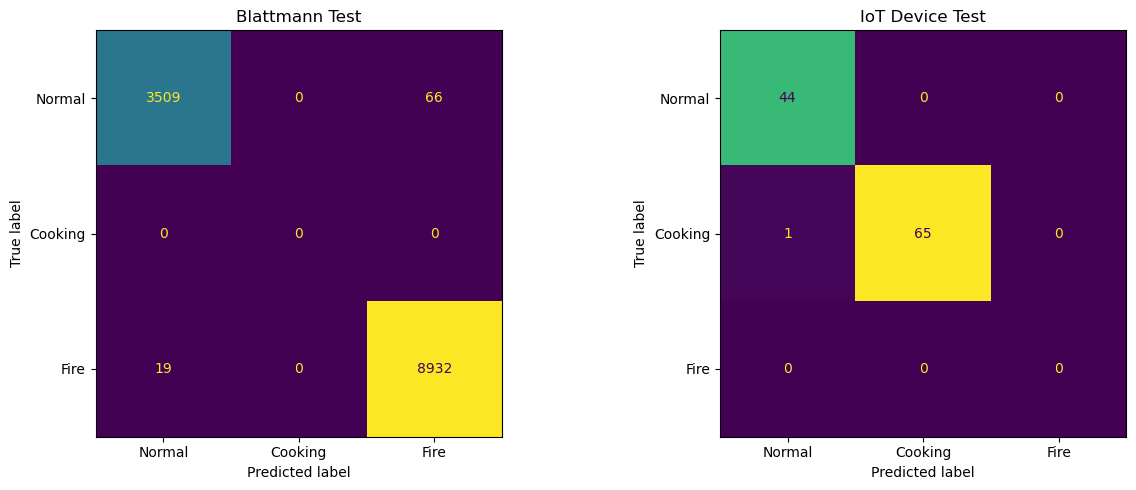

Cooking -> Fire errors in IoT: 0


In [18]:
# Plot confusion matrices for both test sets.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_blattmann_test, y_blattmann_pred, 'Blattmann Test'),
    (axes[1], y_iot_test, y_iot_pred, 'IoT Device Test'),
]:
    matrix = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

print('Cooking -> Fire errors in IoT:', confusion_matrix(y_iot_test, y_iot_pred, labels=[0, 1, 2])[1][2])


#### 13. Overfitting Check
Compare training F1-score with cross-validation F1-score to check whether the model is overfitting.

In [20]:
# Check for overfitting by comparing train and cross-validation scores.
train_f1 = f1_score(y_train, knn.predict(X_train_sc), average='macro')
cv_f1 = cv_scores.mean()
gap = train_f1 - cv_f1

print(f'Train F1: {train_f1:.4f}  |  CV F1: {cv_f1:.4f}  |  Gap: {gap:.4f}')
print('no overfitting' if gap < 0.02 else 'mild overfitting' if gap < 0.05 else 'overfitting detected')


Train F1: 1.0000  |  CV F1: 0.9821  |  Gap: 0.0179
no overfitting


#### 14. Final Notes

The purpose of this notebook is to test whether KNN can classify smoke-related sensor readings using the same prepared data and evaluation setup as the Random Forest model. The main performance indicators are macro F1-score, per-class precision and recall, and the confusion matrices.

Because KNN depends on distances between samples, scaling is required. The final result should be compared with the Random Forest model to decide whether KNN is strong enough for this use case or mainly useful as a baseline comparison.